# GWASLAB VISUALIZATIONS

### Import data and libraries

In [1]:
import gwaslab as gl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
mytest_ldsc = pd.read_csv("/home/maria/git/SOROLLA/Results/CONTROLS/ldsc_genetic_correlation.csv")
mytest_ldsc.head()

,condition1,dataset1,condition2,dataset2,rg,se,z,p,h2_obs,h2_obs_se,h2_int,h2_int_se,gcov_int,gcov_int_se
0,Bip,BIP2012,TRY,GCST000758,0.0256,0.0630,0.4060,0.6847,0.1377,0.0287,0.8914,0.0225,-0.0127,0.0081
1,SCZ,SCZ2014,Obesity,GCST001475,-0.0364,0.0451,-0.8056,0.4205,0.3532,0.0451,0.9374,0.0087,-0.0008,0.0070
2,SCZ,SCZ2014,College,GCST008396,0.0984,0.0419,2.3491,0.0188,0.0711,0.0063,1.0535,0.0107,-0.0064,0.0080
3,BMI,GCST002783,BMI,RA,0.0253,0.0325,0.7776,0.4368,0.2344,0.0822,0.9364,0.0172,-0.0050,0.0052
4,TRY,GCST000758,trigly,T2D-M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
mytest_ldsc = mytest_ldsc.rename(columns={"condition1":"p1", "condition2":"p2"})
mytest_ldsc.head()

,p1,dataset1,p2,dataset2,rg,se,z,p,h2_obs,h2_obs_se,h2_int,h2_int_se,gcov_int,gcov_int_se
0,Bip,BIP2012,TRY,GCST000758,0.0256,0.0630,0.4060,0.6847,0.1377,0.0287,0.8914,0.0225,-0.0127,0.0081
1,SCZ,SCZ2014,Obesity,GCST001475,-0.0364,0.0451,-0.8056,0.4205,0.3532,0.0451,0.9374,0.0087,-0.0008,0.0070
2,SCZ,SCZ2014,College,GCST008396,0.0984,0.0419,2.3491,0.0188,0.0711,0.0063,1.0535,0.0107,-0.0064,0.0080
3,BMI,GCST002783,BMI,RA,0.0253,0.0325,0.7776,0.4368,0.2344,0.0822,0.9364,0.0172,-0.0050,0.0052
4,TRY,GCST000758,trigly,T2D-M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
bulik_ldsc = pd.read_csv("/home/maria/git/SOROLLA/Results/CONTROLS/results_bulik.csv")
bulik_ldsc.head()

,Trait1,Trait2,rg,se,z,p
0,ADHD,Age at Menarche,-0.153,0.08218,-1.858,0.063
1,ADHD,Age at Smoking,-0.036,0.24270,-0.147,0.883
2,ADHD,Alzheimer's,-0.055,0.21910,-0.249,0.803
3,ADHD,Anorexia,0.192,0.11620,1.649,0.099
4,ADHD,Autism Spectrum,-0.164,0.14380,-1.144,0.253


In [7]:
bulik_ldsc = bulik_ldsc.rename(columns={"Trait1":"p1", "Trait2":"p2"})
bulik_ldsc.head()

,p1,p2,rg,se,z,p
0,ADHD,Age at Menarche,-0.153,0.08218,-1.858,0.063
1,ADHD,Age at Smoking,-0.036,0.24270,-0.147,0.883
2,ADHD,Alzheimer's,-0.055,0.21910,-0.249,0.803
3,ADHD,Anorexia,0.192,0.11620,1.649,0.099
4,ADHD,Autism Spectrum,-0.164,0.14380,-1.144,0.253


In [8]:
labels_test_p1 = mytest_ldsc["p1"].unique()
print(labels_test_p1)
labels_test_p2 = mytest_ldsc["p2"].unique()
print(labels_test_p2)

labels_bulik = bulik_ldsc["p1"].unique()
print(labels_bulik)

['Bip' 'SCZ' 'BMI' 'TRY' 'ASD' 'College' 'Obesity' 'DEP' 'ALZ' nan 'LDL'
 'HDL' 'CAD']
['TRY' 'Obesity' 'College' 'BMI' 'trigly' 'DEP' 'college.txt' 'SCZ'
 'education' 'obesity' 'T2D-M' nan 'LDL' 'HDL' 'T2D-F' 'CAD' 'ALZ' 'RA'
 'Bip']
['ADHD' 'Age at Menarche' 'Age at Smoking' "Alzheimer's" 'Anorexia'
 'Autism Spectrum' 'BMI' 'BMI 2010' 'Bipolar' 'Birth Length'
 'Birth Weight' 'Childhood IQ' 'Childhood Obesity' 'Cigarettes per Day'
 'College' 'Coronary Artery Disease' "Crohn's Disease" 'Depression'
 'Ever/Never Smoked' 'Extreme BMI' 'Extreme Height' 'Fasting Glucose'
 'Fasting Insulin' 'Fasting Proinsulin' 'Former/Current Smoker' 'HDL'
 'HOMA-B' 'HOMA-IR' 'HbA1C' 'Height' 'Height 2010' 'Hip Circumference'
 'Infant Head Circumference' 'LDL' 'Lumbar Spine BMD' 'Neck BMD'
 'Obesity Class 1' 'Obesity Class 2' 'Obesity Class 3' 'Overweight'
 'Rheumatoid Arthritis' 'Schizophrenia' 'T2D' 'Total Cholesterol'
 'Triglycerides' 'Ulcerative Colitis' 'Waist Circumference'
 'Waist-Hip Ratio']


In [11]:
replace_values = {
    "ASD": "Autism Spectrum",
    "TRY": "Triglycerides",
    "Bip": "Bipolar",
    "SCZ": "Schizophrenia",
    "Obesity": "Childhood Obesity",
    "DEP": "Depression",
    "college.txt": "College",
    "ALZ": "Alzheimer's",
	"CAD":"Coronary Artery Disease",
	"education":"College",
	"obesity":"Childhood Obesity",
	"trigly": "Triglycerides",
	"RA":"Rheumatoid Arthritis"
}

# Replace values in columns p1 and p2
mytest_ldsc[["p1", "p2"]] = mytest_ldsc[["p1", "p2"]].replace(replace_values)

In [12]:
labels_test_p1 = mytest_ldsc["p1"].unique()
print(labels_test_p1)
labels_test_p2 = mytest_ldsc["p2"].unique()
print(labels_test_p2)

['Bipolar' 'Schizophrenia' 'BMI' 'Triglycerides' 'Autism Spectrum'
 'College' 'Childhood Obesity' 'Depression' "Alzheimer's" nan 'LDL' 'HDL'
 'Coronary Artery Disease']
['Triglycerides' 'Childhood Obesity' 'College' 'BMI' 'Depression'
 'Schizophrenia' 'T2D-M' nan 'LDL' 'HDL' 'T2D-F' 'Coronary Artery Disease'
 "Alzheimer's" 'Rheumatoid Arthritis' 'Bipolar']


In [13]:
mytest_ldsc = mytest_ldsc.dropna(subset=["rg"])
display(mytest_ldsc)

,p1,dataset1,p2,dataset2,rg,se,z,p,h2_obs,h2_obs_se,h2_int,h2_int_se,gcov_int,gcov_int_se
0,Bipolar,BIP2012,Triglycerides,GCST000758,0.0256,0.0630,0.4060,6.847000e-01,0.1377,0.0287,0.8914,0.0225,-0.0127,0.0081
1,Schizophrenia,SCZ2014,Childhood Obesity,GCST001475,-0.0364,0.0451,-0.8056,4.205000e-01,0.3532,0.0451,0.9374,0.0087,-0.0008,0.0070
2,Schizophrenia,SCZ2014,College,GCST008396,0.0984,0.0419,2.3491,1.880000e-02,0.0711,0.0063,1.0535,0.0107,-0.0064,0.0080
3,BMI,GCST002783,BMI,RA,0.0253,0.0325,0.7776,4.368000e-01,0.2344,0.0822,0.9364,0.0172,-0.0050,0.0052
5,Autism Spectrum,ASD2013,Depression,MDD2012,0.7399,0.0619,11.9575,5.931300e-33,0.1270,0.0276,1.0242,0.0094,0.5737,0.0083
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,College,GCST002047,College,LDL,-0.1205,0.0513,-2.3464,1.900000e-02,0.0899,0.0188,0.9717,0.0303,-0.0122,0.0060
112,Autism Spectrum,ASD2013,BMI,GCST002783,-0.0624,0.0341,-1.8294,6.730000e-02,0.1375,0.0096,0.7242,0.0163,-0.0002,0.0074
113,College,GCST008396,College,years,-0.2560,0.0558,-4.5882,4.471300e-06,0.3390,0.0435,0.9429,0.0083,0.0046,0.0055
115,Alzheimer's,GCST002245,College,GCST002047,-0.3105,0.0792,-3.9211,8.815000e-05,0.0659,0.0058,1.0548,0.0100,-0.0129,0.0060


In [14]:
print(mytest_ldsc.columns)
print(bulik_ldsc.columns)

Index(['p1', 'dataset1', 'p2', 'dataset2', 'rg', 'se', 'z', 'p', 'h2_obs',
       'h2_obs_se', 'h2_int', 'h2_int_se', 'gcov_int', 'gcov_int_se'],
      dtype='object')
Index(['p1', 'p2', 'rg', 'se', 'z', 'p'], dtype='object')


In [15]:
mytest_ldsc.drop(['h2_obs', 'h2_obs_se', 'h2_int', 'h2_int_se', 'gcov_int', 'gcov_int_se'], axis=1, inplace=True)
print(mytest_ldsc.columns)

Index(['p1', 'dataset1', 'p2', 'dataset2', 'rg', 'se', 'z', 'p'], dtype='object')


In [16]:
#Merge the datasets into a single table.
merged_test_bulik = merged_df = pd.merge(mytest_ldsc, bulik_ldsc, on=["p1", "p2"], suffixes=('_mytest', '_bulik'))
display(merged_test_bulik)

,p1,dataset1,p2,dataset2,rg_mytest,se_mytest,z_mytest,p_mytest,rg_bulik,se_bulik,z_bulik,p_bulik
0,Bipolar,BIP2012,Triglycerides,GCST000758,0.0256,0.0630,0.4060,6.847000e-01,-0.053000,0.06413,-0.822,4.111000e-01
1,Autism Spectrum,ASD2013,Depression,MDD2012,0.7399,0.0619,11.9575,5.931300e-33,0.215000,0.14390,1.494,1.352000e-01
2,Autism Spectrum,ASD2013,Schizophrenia,SCZ2014,0.9532,0.0324,29.4193,3.106900e-190,0.140000,0.08554,1.637,1.016000e-01
3,Bipolar,BIP2012,College,GCST002047,0.2620,0.0736,3.5589,4.000000e-04,0.261000,0.06691,3.898,9.692000e-05
4,Bipolar,BIP2012,Childhood Obesity,GCST001475,0.0086,0.0718,0.1201,9.044000e-01,0.060000,0.06854,0.883,3.775000e-01
5,Alzheimer's,GCST002245,BMI,GCST002783,-0.0166,0.0511,-0.3244,7.457000e-01,0.031000,0.06057,0.507,6.120000e-01
6,Depression,MDD2012,Triglycerides,GCST000758,0.1834,0.0810,2.2627,2.370000e-02,0.185200,0.08514,2.175,2.965000e-02
7,Bipolar,BIP2012,Schizophrenia,SCZ2014,0.7839,0.0437,17.9275,7.195200e-72,0.794000,0.03862,20.552,7.447000e-94
8,Autism Spectrum,ASD2013,LDL,GCST000759,-0.0336,0.0519,-0.6476,5.172000e-01,-0.046000,0.07469,-0.622,5.338000e-01
9,Depression,MDD2012,Schizophrenia,SCZ2014,0.5364,0.0790,6.7901,1.120600e-11,0.508300,0.07512,6.767,1.319000e-11


In [17]:
merged_only_rg_p = merged_test_bulik[["p1","p2","rg_bulik","rg_mytest","p_bulik","p_mytest"]]
display(merged_only_rg_p)

,p1,p2,rg_bulik,rg_mytest,p_bulik,p_mytest
0,Bipolar,Triglycerides,-0.053000,0.0256,4.111000e-01,6.847000e-01
1,Autism Spectrum,Depression,0.215000,0.7399,1.352000e-01,5.931300e-33
2,Autism Spectrum,Schizophrenia,0.140000,0.9532,1.016000e-01,3.106900e-190
3,Bipolar,College,0.261000,0.2620,9.692000e-05,4.000000e-04
4,Bipolar,Childhood Obesity,0.060000,0.0086,3.775000e-01,9.044000e-01
5,Alzheimer's,BMI,0.031000,-0.0166,6.120000e-01,7.457000e-01
6,Depression,Triglycerides,0.185200,0.1834,2.965000e-02,2.370000e-02
7,Bipolar,Schizophrenia,0.794000,0.7839,7.447000e-94,7.195200e-72
8,Autism Spectrum,LDL,-0.046000,-0.0336,5.338000e-01,5.172000e-01
9,Depression,Schizophrenia,0.508300,0.5364,1.319000e-11,1.120600e-11


In [18]:
merged_only_rg_p.columns

Index(['p1', 'p2', 'rg_bulik', 'rg_mytest', 'p_bulik', 'p_mytest'], dtype='object')

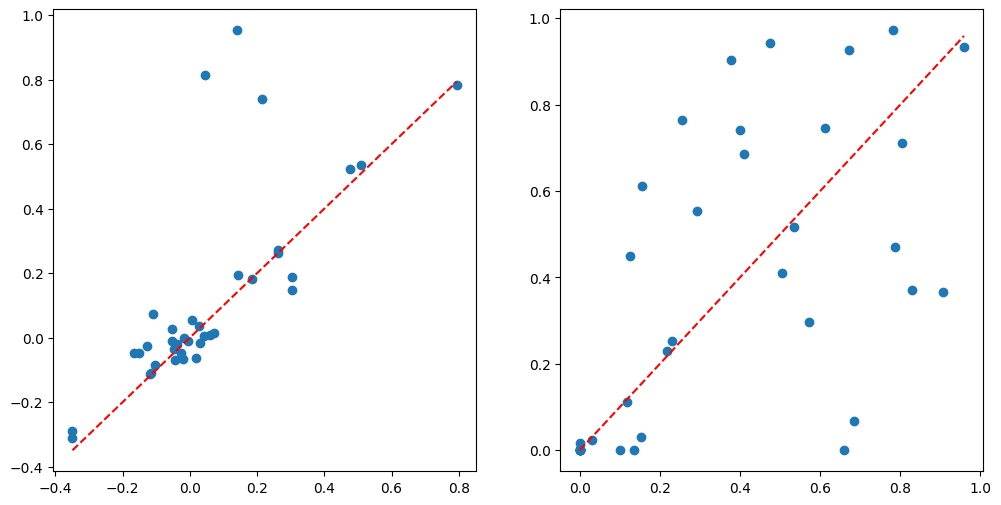

In [24]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))

ax1.scatter(merged_only_rg_p["rg_bulik"],merged_only_rg_p["rg_mytest"])
ax1.plot([merged_only_rg_p["rg_bulik"].min(), merged_only_rg_p["rg_bulik"].max()], 
         [merged_only_rg_p["rg_bulik"].min(), merged_only_rg_p["rg_bulik"].max()], 
         linestyle='--', color='red', label='y=x line')
ax2.scatter(merged_only_rg_p["p_bulik"],merged_only_rg_p["p_mytest"])
ax2.plot([merged_only_rg_p["p_bulik"].min(), merged_only_rg_p["p_bulik"].max()], 
         [merged_only_rg_p["p_bulik"].min(), merged_only_rg_p["p_bulik"].max()], 
         linestyle='--', color='red', label='y=x line')


In [71]:
list_values_to_keep_from_test_1 = mytest_ldsc["p1"].unique()
print(list_values_to_keep_from_test_1)
list_values_to_keep_from_test_2 = mytest_ldsc["p2"].unique()
print(list_values_to_keep_from_test_2)

['Bipolar' 'Schizophrenia' 'BMI' 'Autism Spectrum' 'College'
 'Childhood Obesity' 'Depression' "Alzheimer's" 'Triglycerides' 'LDL'
 'Coronary Artery Disease' 'HDL']
['Triglycerides' 'Childhood Obesity' 'College' 'BMI' 'Depression'
 'Schizophrenia' 'LDL' 'Coronary Artery Disease' "Alzheimer's" 'HDL'
 'Rheumatoid Arthritis' 'Bipolar']


In [72]:
subset_bulik = bulik_ldsc[bulik_ldsc["p1"].isin(list_values_to_keep_from_test_1) & bulik_ldsc["p2"].isin(list_values_to_keep_from_test_2)]

## Heatmap

2024/07/01 16:31:08 Start to create ldsc genetic correlation heatmap...
2024/07/01 16:31:08 Raw dataset records: 91
2024/07/01 16:31:08  -Raw dataset non-NA records: 91
2024/07/01 16:31:08 Filling diagnal line and duplicated pair for plotting...
2024/07/01 16:31:08  -Diagnal records: 11
2024/07/01 16:31:08 Valid unique trait pairs: 50
2024/07/01 16:31:08  -Valid unique trait1: 5
2024/07/01 16:31:08  -Valid unique trait2: 12
2024/07/01 16:31:08  -Significant correlations with P < 0.05: 14
2024/07/01 16:31:08  -Significant correlations after Bonferroni correction: 9
2024/07/01 16:31:08  -Significant correlations with FDR <0.05: 10
2024/07/01 16:31:08 Plotting heatmap...
2024/07/01 16:31:08 Full cell : non-corrected P == 0.05
2024/07/01 16:31:08 P value annotation text (Order: Bon -> FDR -> Pnom): 
2024/07/01 16:31:08  -* : non-corrected P < 0.05 


2024/07/01 16:31:08 Start to save figure...
2024/07/01 16:31:08  -Skip saving figure!
2024/07/01 16:31:08 Finished saving figure...
2024/07/01 16:31:08 Finished creating ldsc genetic correlation heatmap!


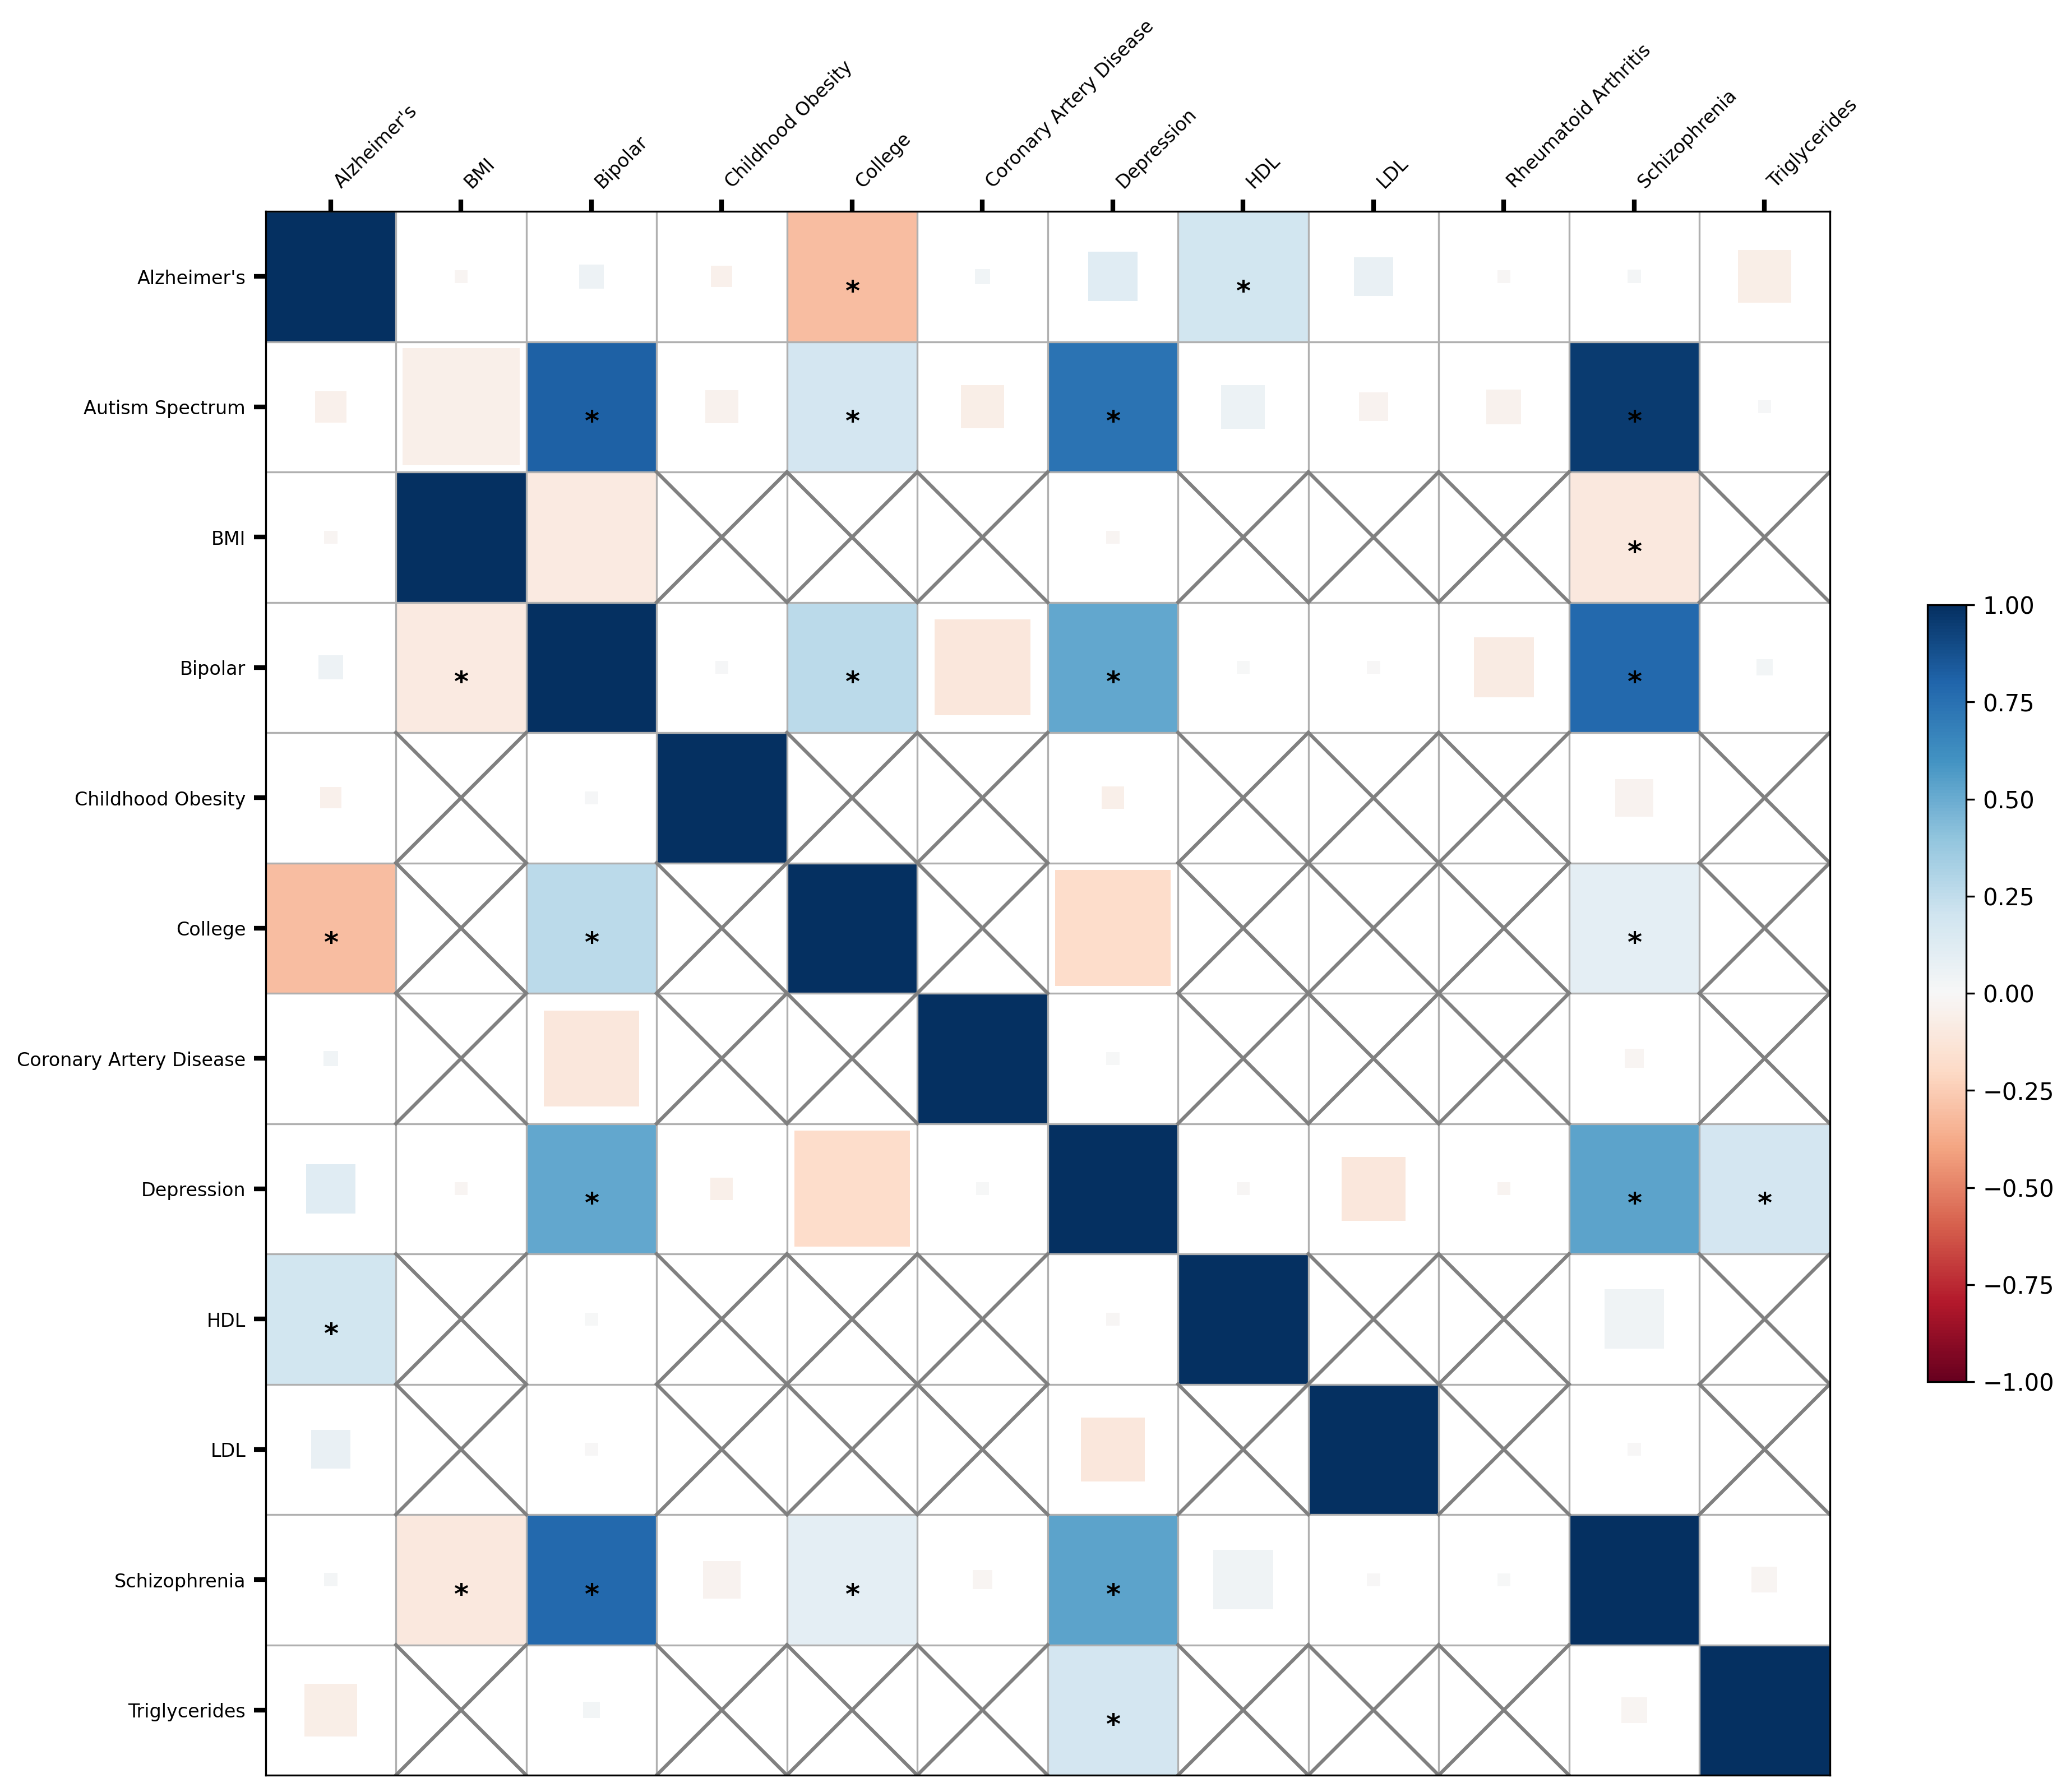

In [62]:
test_heatmap = gl.plot_rg(
    mytest_ldsc,
    p="p",
    p1="p1",
    p2="p2",
    sig_levels=[0.05],
    corrections =["non"],
    full_cell=("non",0.05),
    panno_texts=["*"],
    panno_args={"size":12,"c":"black"},
    fig_args={"figsize":(15,15),"dpi":300},
    colorbar_args={"shrink":0.4},
    fontsize=8
	)


2024/07/01 16:39:36 Start to create ldsc genetic correlation heatmap...
2024/07/01 16:39:36 Raw dataset records: 75
2024/07/01 16:39:36  -Raw dataset non-NA records: 75
2024/07/01 16:39:36 Filling diagnal line and duplicated pair for plotting...
2024/07/01 16:39:36  -Diagnal records: 9
2024/07/01 16:39:36 Valid unique trait pairs: 75
2024/07/01 16:39:36  -Valid unique trait1: 11
2024/07/01 16:39:36  -Valid unique trait2: 11
2024/07/01 16:39:36  -Significant correlations with P < 0.05: 26
2024/07/01 16:39:36  -Significant correlations after Bonferroni correction: 20
2024/07/01 16:39:36  -Significant correlations with FDR <0.05: 22
2024/07/01 16:39:36 Plotting heatmap...
2024/07/01 16:39:36 Full cell : non-corrected P == 0.05
2024/07/01 16:39:36 P value annotation text (Order: Bon -> FDR -> Pnom): 
2024/07/01 16:39:36  -* : non-corrected P < 0.05 
2024/07/01 16:39:36 Start to save figure...
2024/07/01 16:39:36  -Skip saving figure!
2024/07/01 16:39:36 Finished saving figure...
2024/07/01

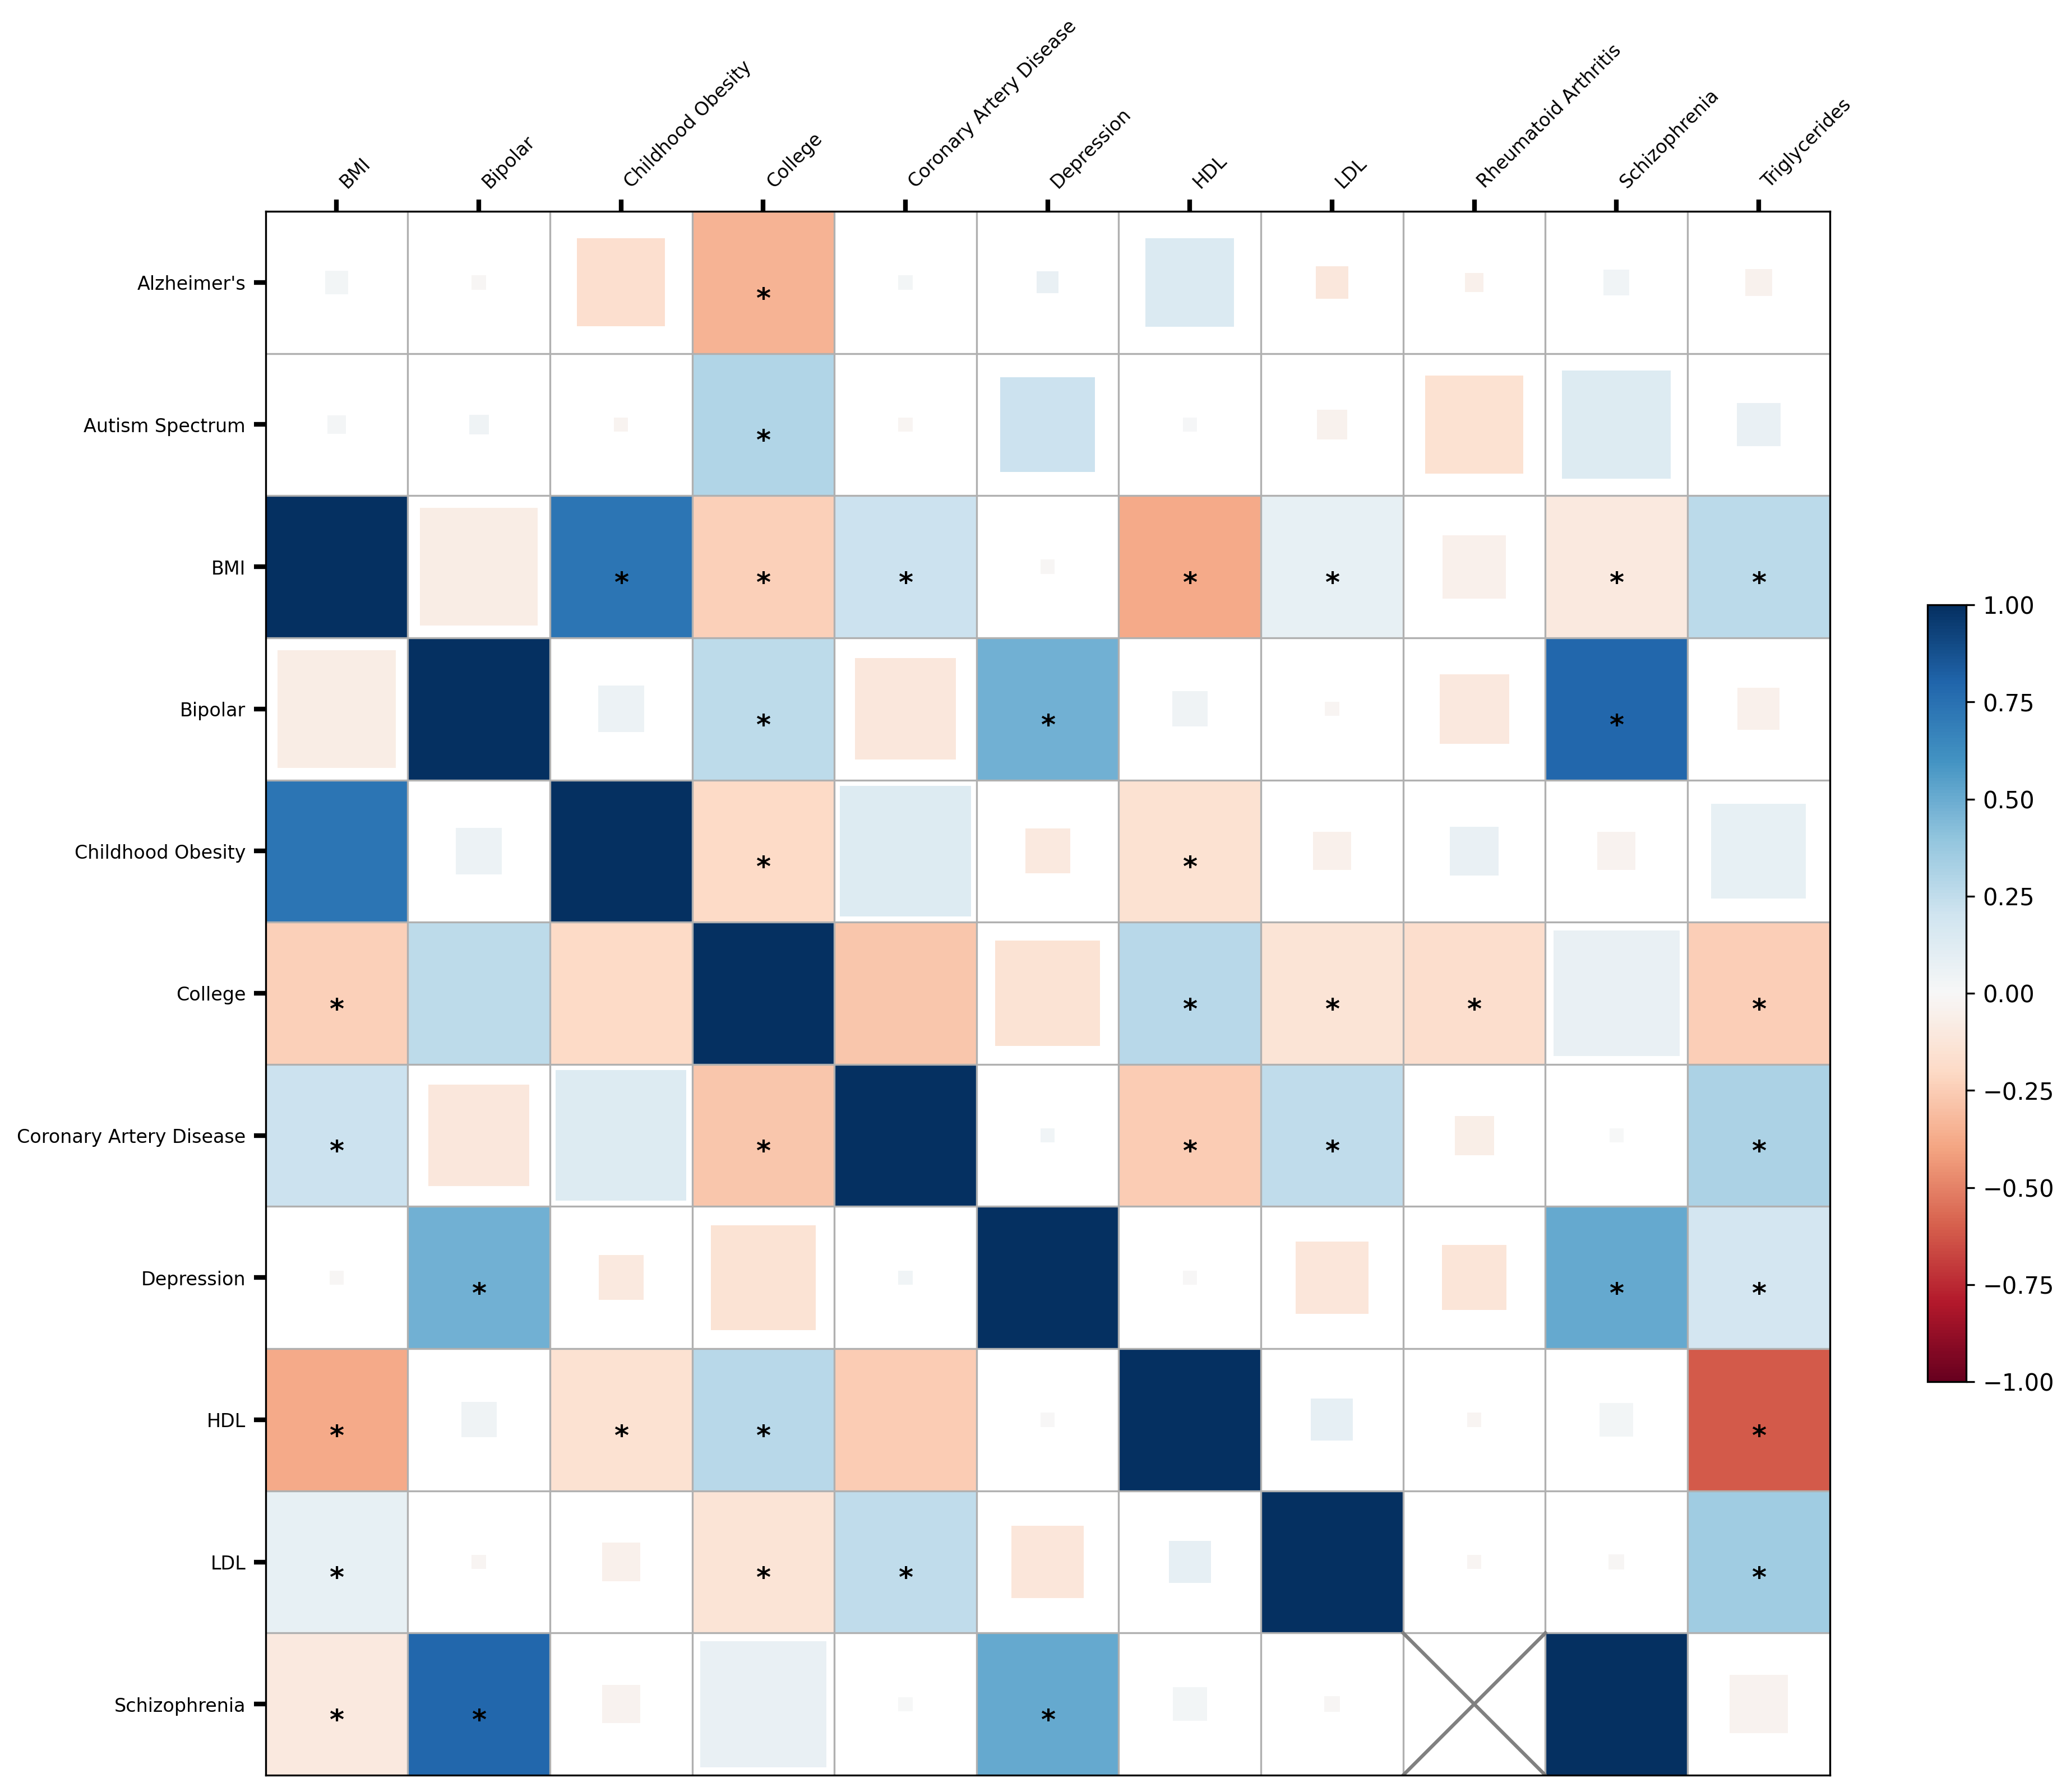

In [73]:
bulik_heatmap = gl.plot_rg(
    subset_bulik,
    p="p",
    p1="p1",
    p2="p2",
    sig_levels=[0.05],
    corrections =["non"],
    full_cell=("non",0.05),
    panno_texts=["*"],
    panno_args={"size":12,"c":"black"},
    fig_args={"figsize":(15,15),"dpi":300},
    colorbar_args={"shrink":0.4},
    fontsize=8
	)
